## need to validate equation 5 and (basically) the volume transport.

Notes post An meeting 3/6:
- think about this in terms of limits
- we will need to run this a couple of times with a different dT and dS for the bins
- maybe we can turn this into a manual based on input dT and dS -- show the residual is bigger as the dT approaches 0

## Set up the grid

In [127]:
# going to try to run this with the validated J terms for a single cell.

In [128]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(450, 90)
RAC2d (40500,)
(100,)


In [129]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [130]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

## decide the width of the T bins

I don't want to read this from file, I want to do this by reading from the bin edges and defining the number of bins we want in T and S.

In [137]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

# --- Define bin count and recompute uniform edges ---
# adding a number of bins here will allow us to perform the limit for small/large nT or nS
nT = 70
nS = 70

nT = 150
nS = 150

T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Tbin3,Sbin3 = np.meshgrid(bincentTp,bincentSp) # for plotting the convergence of the J vectors

In [138]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [139]:
# create the iwet for a specific, singular column with two cells.
iy,ix = 150,19

In [140]:
# create iwet from a mask at these points
mymsk = np.full((ny,nx),np.nan)
mymsk[iy,ix] = 1
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [141]:
mymsk_faces = get_aste_faces(mymsk,nfx,nfy)
a = mymsk_faces.f3[0]
np.where(~np.isnan(a))                               # double checking this is the same one An has provided

(array([0]), array([19]))

## Load the (previously validated) J terms

In [142]:
# plt.pcolormesh(mymsk)

In [143]:
# create the same Jy offline as done before

from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

dt = 1800
termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)
termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,mapping=True)


In [144]:
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

In [145]:
def bin_3d_term_to_TS(term3d, THETA, SALT, mymsk3d, binmidT, binmidS, binwidthT1, binwidthS1):
    nT = len(binmidT)
    nS = len(binmidS)

    dF_TS = np.zeros((nT-1, nS-1), dtype=float)
    L_TS  = np.zeros((nT-1, nS-1), dtype=int)

    # Flatten
    T_flat = np.ravel(THETA * mymsk3d, order="F")
    S_flat = np.ravel(SALT  * mymsk3d, order="F")
    X_flat = np.ravel(term3d * mymsk3d, order="F")

    # Bin indices
    iT = np.searchsorted(binmidT, T_flat, side="right") - 1
    iS = np.searchsorted(binmidS, S_flat, side="right") - 1

    # Valid points
    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(X_flat)
    iT = iT[ok]
    iS = iS[ok]
    vals = X_flat[ok]

    # Accumulate
    np.add.at(dF_TS, (iT, iS), vals)
    np.add.at(L_TS,  (iT, iS), 1)

    # Normalize by both bin widths
    dA = binwidthT1[:, None] * binwidthS1[None, :]  # An suggests doing this separately in future
                                                    # first division in dT or dS gets you G_T or G_S
                                                    # second division by dS or dT gets you the J component of J_S or J_T
    G_TS = dF_TS / dA                               # should not be called G_TS here!

    return G_TS, dF_TS, L_TS

termsT_TS = {}   # inputs as degC.m^3/s, out as m^3/s/PSU, same as layers Jy
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

termsS_TS = {}   # inputs as PSU.m^3/s, out as m^3/s/degC, same as layers Jx
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

In [146]:
np.where(termsT_TS['tend']!=0)

(array([2]), array([124]))

In [147]:
# # get the M term as a TS diagram for the T and S
# # there are two gates, and two face temperature values
# TH_N = (THETA[:,iy,ix] + THETA[:,iy+1,ix])/2
# TH_W = (THETA[:,iy,ix] + THETA[:,iy,ix-1])/2

# SLT_N = (SALT[:,iy,ix] + SALT[:,iy+1,ix])/2
# SLT_W = (SALT[:,iy,ix] + SALT[:,iy,ix-1])/2

# print(TH_N[:2], TH_W[:2], SLT_N[:2], SLT_W[:2])

# print(T_centers[1:3])     # for both bins at iT
# print(S_centers[83:85])   # for the top and bottom bins in SLT

In [148]:
# define ADVy and ADVx

# get the Msum from ADVx and ADVy of the terms
file_name = "budg3d_hflux_set2"
meta_budg3d_hflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_hflux_set2["fldList"])
varnames = np.array(["ADVx_TH","ADVy_TH","ADVx_SLT","ADVy_SLT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
ADVx_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
ADVy_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
ADVx_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
ADVy_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[3])

ADVx_TH = ADVx_TH.reshape((nz,ny,nx)) # degC.m^3/s
ADVy_TH = ADVy_TH.reshape((nz,ny,nx)) 
ADVx_SLT = ADVx_SLT.reshape((nz,ny,nx)) # PSU.m^3/s
ADVy_SLT = ADVy_SLT.reshape((nz,ny,nx))

In [149]:
def bin_face_flux_to_TS(flux_z, T_face_z, S_face_z, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d=None):
    """
    Bin a vertical column of face fluxes into (T,S) space.
    flux_z, T_face_z, S_face_z are all 1D arrays of length nz.
    """
    nT = len(binmidT)
    nS = len(binmidS)
    dF_TS = np.zeros((nT-1, nS-1), dtype=float)

    if mymsk1d is not None:
        valid = mymsk1d.astype(bool)
        flux_z   = flux_z[valid]
        T_face_z = T_face_z[valid]
        S_face_z = S_face_z[valid]

    # Bin indices using same logic as bin_3d_term_to_TS
    iT = np.searchsorted(binmidT, T_face_z, side="right") - 1
    iS = np.searchsorted(binmidS, S_face_z, side="right") - 1

    ok = (iT >= 0) & (iT < nT-1) & (iS >= 0) & (iS < nS-1) & np.isfinite(flux_z)
    np.add.at(dF_TS, (iT[ok], iS[ok]), flux_z[ok])

    # Normalize by bin areas
    dA = binwidthT1[:, None] * binwidthS1[None, :]
    return dF_TS / dA, dF_TS


# --- Face-averaged T and S at each gate ---
TH_N  = (THETA[:,iy,ix] + THETA[:,iy+1,ix]) / 2   # north gate
TH_W  = (THETA[:,iy,ix] + THETA[:,iy,ix-1]) / 2   # west gate
SLT_N = (SALT[:,iy,ix]  + SALT[:,iy+1,ix])  / 2
SLT_W = (SALT[:,iy,ix]  + SALT[:,iy,ix-1])  / 2

# --- Raw face fluxes (sign convention: into the cell is positive) ---
M_NT_z = -ADVy_TH[:,iy+1,ix]    # north face, heat
M_NS_z = -ADVy_SLT[:,iy+1,ix]   # north face, salt
M_WT_z =  ADVx_TH[:,iy,ix]      # west face,  heat
M_WS_z =  ADVx_SLT[:,iy,ix]     # west face,  salt

mymsk1d = mymsk3d[:,iy,ix]  # 1D mask for this column

# --- Bin each gate flux by face-averaged (T,S) ---
M_T_N, _ = bin_face_flux_to_TS(M_NT_z, TH_N,  SLT_N, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)
M_T_W, _ = bin_face_flux_to_TS(M_WT_z, TH_W,  SLT_W, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)
M_S_N, _ = bin_face_flux_to_TS(M_NS_z, TH_N,  SLT_N, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)
M_S_W, _ = bin_face_flux_to_TS(M_WS_z, TH_W,  SLT_W, binmidT, binmidS, binwidthT1, binwidthS1, mymsk1d)

# --- Sum gates to get total M_T and M_S ---
M_T = M_T_N + M_T_W   # [nTm1, nSm1]
M_S = M_S_N + M_S_W   # [nTm1, nSm1]

# --- Sanity check: print the bins at the known point ---
print("M_T sum:", np.nansum(M_T)*1e-6)        # m^3/s/PSU
print("M_S sum:", np.nansum(M_S)*1e-6)        # m^3/s/degC
# these should be the same values as ADVh, yes this is verified.

M_T sum: -0.01589253436590539
M_S sum: 0.27696324728720845


In [150]:
# quickly validate the gate term again here with ADVh
print(np.nansum(termsT_TS["ADVh"])*1e-6,"Sv/PSU")
print(np.nansum(termsS_TS["ADVh"])*1e-6,"Sv/degC")

-0.015892534365905393 Sv/PSU
0.2769632472872082 Sv/degC


## now plot the divergence of these terms

In [151]:
# write an example function which takes the Jy (T in Sv/PSU) term and the Jx (S in Sv/degC) term and returns the divergence
# as normalized by the dT_edges[1:-1] (shape nT-2)

def get_div(Jy, Jx, dT_edges, dS_edges):
    '''
    inputs:
        Jy: transport in T direction, shape (nT-1, nS-1), units of m^3/s/PSU
        Jx: transport in S direction, shape (nT-1, nS-1), units of m^3/s/degC
        dT_edges: T-bin widths for interior T differences, shape (nT-2,)
        dS_edges: S-bin widths for interior S differences, shape (nS-2,)

    outputs:
        gradJ: divergence on interior cell centers, shape (nT-2, nS-2), units of Sv/PSU/degC
    '''

    # Difference in T direction: shape (nT-2, nS-1)
    dJy = Jy[1:, :] - Jy[:-1, :]            # m^3/s/PSU

    # Difference in S direction: shape (nT-1, nS-2)
    dJx = Jx[:, 1:] - Jx[:, :-1]            # m^3/s/degC

    # Divide by bin widths
    # dT_edges[:, None] broadcasts across S
    dJydT = dJy / dT_edges[1:-1, None]      # (nT-2, nS-1);  m^3/s/PSU -->   m^3/s/PSU/degC

    # dS_edges[None, :] broadcasts across T
    dJxdS = dJx / dS_edges[None, 1:-1]      # (nT-1, nS-2);  m^3/s/degC -->  m^3/s/degC/PSU

    # Center to common interior points (nT-2, nS-2)
    dJydT_center = 0.5 * (dJydT[:, 1:] + dJydT[:, :-1])
    dJxdS_center = 0.5 * (dJxdS[1:, :] + dJxdS[:-1, :])

    gradJ = -(dJydT_center + dJxdS_center)                # we set so that + is creation

    return gradJ * 1e-6                                   # Sv/PSU/degC


In [152]:
T_keys = list(termsT_TS.keys())
S_keys = list(termsS_TS.keys())

# total tendency
dVdt = get_div(termsT_TS['tend'], termsS_TS['tend'], dT_edges, dS_edges)

# example single term
divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_edges, dS_edges)

# internal = sum of terms at positions 1,2,3,5
internal_inds = [1, 2, 3, 5]

divint = sum(
    get_div(termsT_TS[T_keys[i]], termsS_TS[S_keys[i]], dT_edges, dS_edges)
    for i in internal_inds
)

# surface = term at position 4
surface_ind = 4
divsurf = get_div(
    termsT_TS[T_keys[surface_ind]],
    termsS_TS[S_keys[surface_ind]],
    dT_edges,
    dS_edges
)

div_gates = get_div(M_T,M_S,dT_edges,dS_edges)

(-2.0, 0.0)

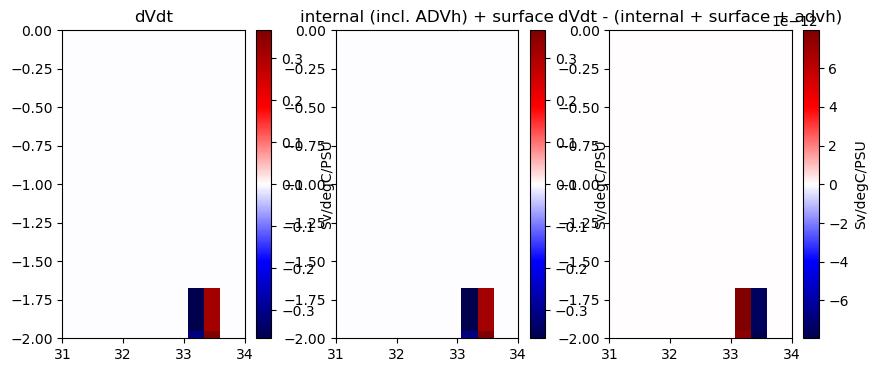

In [153]:
fig = plt.figure()

# plot each of the above and a sum of them

ax = plt.subplot(131)
lhs = dVdt
cb = ax.pcolormesh(Sbin3,Tbin3,dVdt.T,cmap='seismic')
ax.set_title("dVdt")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(132)
rhs = divADVh + divint + divsurf
ax.set_title("internal (incl. ADVh) + surface")
cb = ax.pcolormesh(Sbin3,Tbin3,rhs.T,cmap='seismic')
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

ax = plt.subplot(133)
ax.set_title("dVdt - (internal + surface + advh)")
cb = ax.pcolormesh(Sbin3,Tbin3,(rhs-lhs).T,cmap='seismic')
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(31,34)
ax.set_ylim(-2,0)

Text(0.5, 0.98, 'Residual at dT=0.28 and dS=0.27')

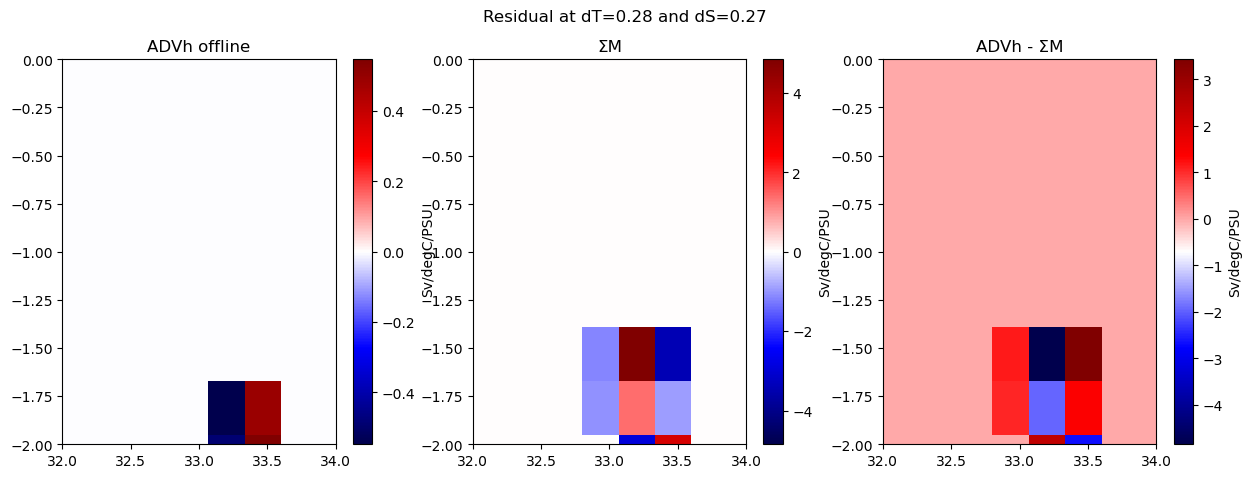

In [154]:
# great, now look at the gateway term in TS as compared to the ADVh term
fig = plt.figure(figsize=(15,5))

# plot each of the above and a sum of them
ax = plt.subplot(131)
cb = ax.pcolormesh(Sbin3,Tbin3,divADVh.T,cmap='seismic')
ax.set_title("ADVh offline")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(32,34)
ax.set_ylim(-2,0)

ax = plt.subplot(132)
vlev = np.nanmax(div_gates)
cb = ax.pcolormesh(Sbin3,Tbin3,div_gates.T,cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_title("ΣM")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(32,34)
ax.set_ylim(-2,0)

ax = plt.subplot(133)
cb = ax.pcolormesh(Sbin3,Tbin3,(divADVh-div_gates).T,cmap='seismic')#,vmin=-3,vmax=3)
ax.set_title("ADVh - ΣM")
plt.colorbar(cb,label="Sv/degC/PSU")
ax.set_xlim(32,34)
ax.set_ylim(-2,0)

plt.suptitle(f"Residual at dT={dT_centers[0]:.2f} and dS={dS_centers[0]:.2f}")


In [155]:
print(np.nanmax((divADVh-div_gates)),"Sv/degC/PSU")
print(np.nanmin((divADVh-div_gates)),"Sv/degC/PSU") # yes because these are being binned to the same value

3.433641779531744 Sv/degC/PSU
-4.846356402995929 Sv/degC/PSU


In [115]:
# great, now try to make the bins bigger (fewer bins) and see if it works

In [119]:
# to do after lunch

# make a function which varies this based on the number of bin sizes
# write some kind of function which plots the total residual as a function of the width of the bin

In [ ]:
# I have a feeling because this is only a 2-cell column, the faces either will or won't be in the base